# 02 · Real listings and price observations
Every see/eat/sleep listing with a parseable ₹ price becomes a cost observation. Daily per-person cost = 3 meals + ~60% of a room night + 2 entry fees + ₹250 local transport (`estimate_daily`).

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = r"C:\xampp\htdocs\travel_journel"
os.chdir(ROOT); sys.path.insert(0, ROOT)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3})
DATA = os.path.join(ROOT, "ml", "data")

In [2]:
L = pd.DataFrame(json.load(open(f"{DATA}/india_listings.json", encoding="utf8")))
O = pd.DataFrame(json.load(open(f"{DATA}/india_cost_observations.json", encoding="utf8")))
C = pd.DataFrame(json.load(open(f"{DATA}/india_catalog.json", encoding="utf8")))
print(len(L), "listings;", len(O), "price observations;", len(C), "destinations")
L.type.value_counts()

16639 listings; 2148 price observations; 441 destinations


type
see         6127
sleep       4160
eat         2688
do          1234
buy          929
listing      819
drink        607
around        56
go            14
vicinity       4
learn          1
Name: count, dtype: int64

In [3]:
O.groupby("type").inr.describe()[["count","25%","50%","75%","max"]]

,count,25%,50%,75%,max
type,,,,,
do,98.0,40.000,164.5,412.875,4750.0
drink,31.0,47.500,125.0,300.000,150000.0
eat,234.0,90.000,170.0,380.000,6150.0
see,258.0,20.625,50.0,125.000,2000.0
sleep,1527.0,600.000,1350.0,3200.000,60000.0


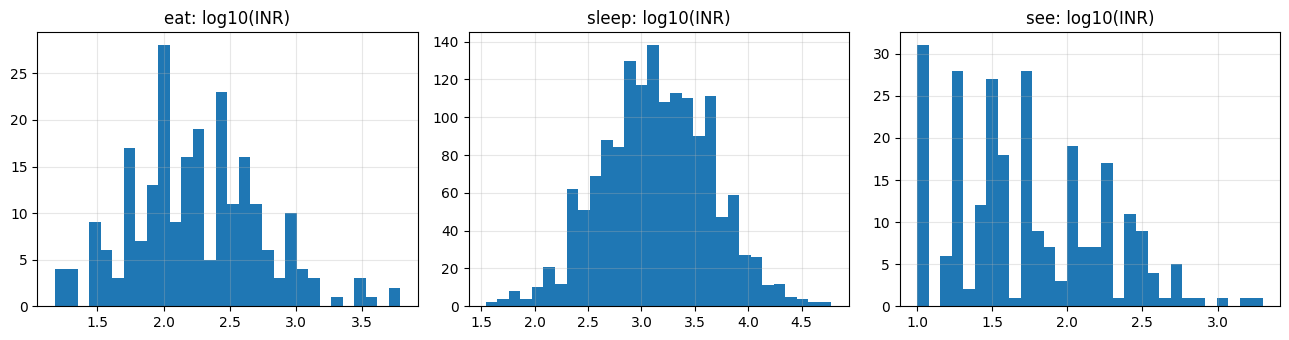

In [4]:
fig,ax = plt.subplots(1,3,figsize=(13,3.5))
for a,t in zip(ax,["eat","sleep","see"]):
    np.log10(O[O.type==t].inr).hist(bins=30, ax=a); a.set_title(f"{t}: log10(INR)")
plt.tight_layout(); plt.show()

In [5]:
C.groupby("region").base_daily_inr.describe()[["count","25%","50%","75%"]].round(0)

,count,25%,50%,75%
region,,,,
Central India,16.0,1300.0,1300.0,1300.0
East India,75.0,1900.0,2050.0,2050.0
Himalayas,48.0,1300.0,1300.0,1362.0
North India,60.0,2750.0,2750.0,2750.0
Northeast India,22.0,3350.0,3350.0,3350.0
South India,133.0,1350.0,1350.0,1350.0
West India,87.0,1950.0,1950.0,1950.0


In [6]:
s = C.sort_values("base_daily_inr")
pd.concat([s.head(8), s.tail(8)])[["name","region","tier","base_daily_inr","n_price_obs"]]

,name,region,tier,base_daily_inr,n_price_obs
434,"Aluva, India",South India,lesser_known,750,7
13,"Leh, India",Himalayas,mainstream,800,12
60,"Mysore, India",South India,mainstream,850,25
344,"Kasaragod, India",South India,mainstream,850,9
189,"Tiruchirappalli, India",South India,mainstream,850,6
294,"Khajuraho, India",Central India,mainstream,1050,7
365,"Thanjavur, India",South India,mainstream,1050,8
67,"Nubra Valley, India",Himalayas,lesser_known,1100,5
14,"Manali, India",Himalayas,mainstream,4600,10
244,"Sawai Madhopur, India",West India,lesser_known,5050,17


In [7]:
print("destinations backed by >=3 direct price observations:", int((C.n_price_obs>=3).sum()), "of", len(C), "(rest use the region median)")

destinations backed by >=3 direct price observations: 176 of 441 (rest use the region median)
